In [3]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

pd.set_option("display.max_colwidth", None)


In [4]:
arrivals_df = pd.read_csv("ED_arrivals.csv")
arrivals_df_before = arrivals_df.copy()
scale_factor = 5   # or 20, or 50 depending on how smooth you want it

arrivals_df["arrivals"] *= scale_factor
arrivals_df["arrivals"] = arrivals_df["arrivals"].astype(float)

arrivals_df


,disease_index,disease_name,t,arrivals
0,1,"Symptoms, signs, and abnormal clinical and laboratory findings",1,5.0
1,1,"Symptoms, signs, and abnormal clinical and laboratory findings",2,5.0
2,1,"Symptoms, signs, and abnormal clinical and laboratory findings",3,5.0
3,1,"Symptoms, signs, and abnormal clinical and laboratory findings",4,5.0
4,1,"Symptoms, signs, and abnormal clinical and laboratory findings",5,5.0
...,...,...,...,...
475,20,Other symptoms or problems related to psychological and mental disorders,20,10.0
476,20,Other symptoms or problems related to psychological and mental disorders,21,10.0
477,20,Other symptoms or problems related to psychological and mental disorders,22,10.0
478,20,Other symptoms or problems related to psychological and mental disorders,23,10.0


In [5]:
arrivals_df["disease_name"]

0                Symptoms, signs, and abnormal clinical and laboratory findings
1                Symptoms, signs, and abnormal clinical and laboratory findings
2                Symptoms, signs, and abnormal clinical and laboratory findings
3                Symptoms, signs, and abnormal clinical and laboratory findings
4                Symptoms, signs, and abnormal clinical and laboratory findings
                                         ...                                   
475    Other symptoms or problems related to psychological and mental disorders
476    Other symptoms or problems related to psychological and mental disorders
477    Other symptoms or problems related to psychological and mental disorders
478    Other symptoms or problems related to psychological and mental disorders
479    Other symptoms or problems related to psychological and mental disorders
Name: disease_name, Length: 480, dtype: object

In [8]:
def generate_arrival_scenario(arrivals_df, hourly_percent, scale_factor=5):

    df = arrivals_df.copy()
    df["arrivals"] = df["arrivals"] * scale_factor

    # step 1: normalize hourly weights
    perc = pd.Series(hourly_percent).sort_index()
    weights = perc / perc.sum()

    # step 2: compute total arrivals (scaled)
    total_daily = (df["arrivals"].sum())

    # desired hourly totals (float)
    float_hour_totals = weights * total_daily

    # smart methods developed by ChatGPT to keep the total daily constant while round up / rounding down when needed
    base_hour = np.floor(float_hour_totals).astype(int)
    remainders = float_hour_totals - base_hour    
    remaining = int(total_daily - base_hour.sum())
    order = np.argsort(-remainders.values)
    int_hour_totals = base_hour.copy()
    for idx in order[:remaining]:
        int_hour_totals[idx] += 1

    # integer hourly totals stored as dict {hour: int}
    hour_to_total = {h: int_hour_totals[h] for h in range(24)}

    # step 3: distribute per symptom for each hour
    df_new = df.copy()

    for t in range(1, 25):
        mask = df_new["t"] == t
        sub = df_new.loc[mask, :]

        old_total = sub["arrivals"].sum()
        target_total = hour_to_total[t - 1]

        if old_total == 0:
            df_new.loc[mask, "arrivals"] = 0
            continue

        # symptom probabilities
        p = sub["arrivals"] / old_total

        # expected symptom totals
        float_sym = p * target_total
        base_sym = np.floor(float_sym).astype(int)
        rem_sym = float_sym - base_sym

        # distribute remainders
        remaining_sym = target_total - base_sym.sum()
        order_sym = np.argsort(-rem_sym.values)

        int_sym = base_sym.copy()
        for idx in order_sym[:remaining_sym]:
            int_sym.iloc[idx] += 1

        df_new.loc[mask, "arrivals"] = int_sym.values

    df_new["arrivals"] = df_new["arrivals"].astype(int)

    return df_new


In [9]:
hourly_percent = {
    0: 2, 1: 2, 2: 3, 3: 1, 4: 1, 5: 2,
    6: 3, 7: 5, 8: 5, 9: 7, 10: 5, 11: 5,
    12: 8, 13: 6, 14: 7, 15: 6, 16: 6, 17: 5,
    18: 4, 19: 4, 20: 4, 21: 3, 22: 3, 23: 3
}

arrivals_df = generate_arrival_scenario(arrivals_df, hourly_percent)

arrivals_df


,disease_index,disease_name,t,arrivals
0,1,"Symptoms, signs, and abnormal clinical and laboratory findings",1,12
1,1,"Symptoms, signs, and abnormal clinical and laboratory findings",2,12
2,1,"Symptoms, signs, and abnormal clinical and laboratory findings",3,18
3,1,"Symptoms, signs, and abnormal clinical and laboratory findings",4,6
4,1,"Symptoms, signs, and abnormal clinical and laboratory findings",5,6
...,...,...,...,...
475,20,Other symptoms or problems related to psychological and mental disorders,20,48
476,20,Other symptoms or problems related to psychological and mental disorders,21,48
477,20,Other symptoms or problems related to psychological and mental disorders,22,36
478,20,Other symptoms or problems related to psychological and mental disorders,23,36


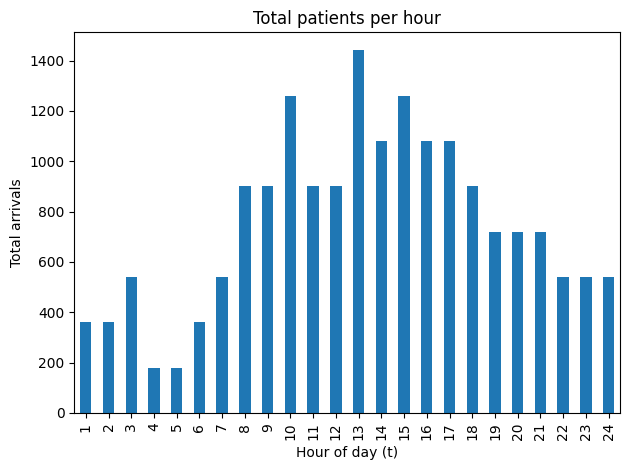

In [10]:
import matplotlib.pyplot as plt

# total arrivals per hour
hourly_total = arrivals_df.groupby("t")["arrivals"].sum()

plt.figure()
hourly_total.plot(kind="bar")
plt.xlabel("Hour of day (t)")
plt.ylabel("Total arrivals")
plt.title("Total patients per hour")
plt.tight_layout()
plt.show()



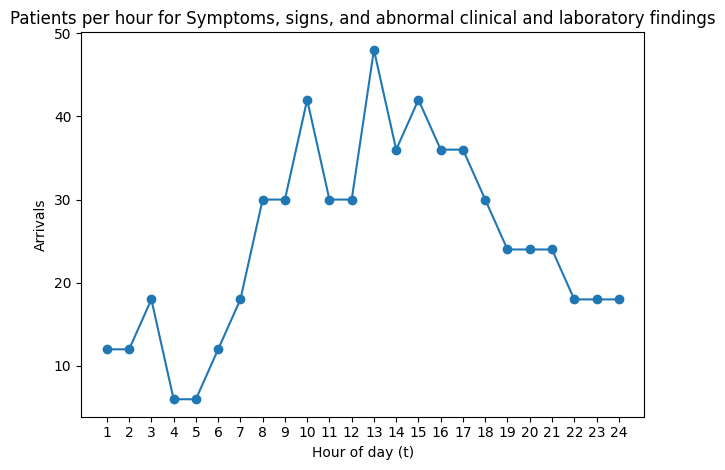

In [11]:

symptom_df = arrivals_df[arrivals_df["disease_name"] == "Symptoms, signs, and abnormal clinical and laboratory findings"].sort_values("t")

plt.figure()
plt.plot(symptom_df["t"], symptom_df["arrivals"], marker="o")
plt.xlabel("Hour of day (t)")
plt.ylabel(f"Arrivals")
plt.title(f"Patients per hour for Symptoms, signs, and abnormal clinical and laboratory findings")
plt.xticks(range(1, 25))
plt.tight_layout()
plt.show()


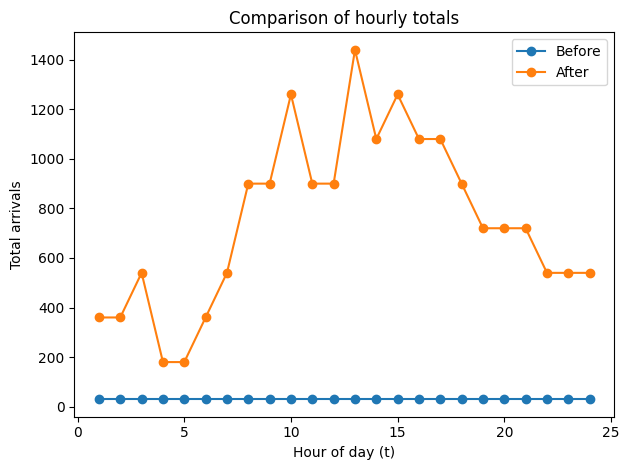

In [12]:
hourly_total_before = arrivals_df_before.groupby("t")["arrivals"].sum()
hourly_total_after  = arrivals_df.groupby("t")["arrivals"].sum()

plt.figure()
plt.plot(hourly_total_before.index, hourly_total_before.values, marker="o", label="Before")
plt.plot(hourly_total_after.index,  hourly_total_after.values,  marker="o", label="After")
plt.xlabel("Hour of day (t)")
plt.ylabel("Total arrivals")
plt.title("Comparison of hourly totals")
plt.legend()
plt.tight_layout()
plt.show()


In [13]:
arrivals_df.to_csv("ED_arrivals_2.csv", index=False)
